# 🤖 Robot Joint Current Monitor
### CSCN8010 · Data Streaming and Visualization Workshop · Use case: robot predictive maintenance

A torque-tube failure on a material-handling robot cost **480 minutes of downtime**. It was age-related wear that nobody could see coming, because nothing watched the robot's health while it worked.

This notebook builds that watcher for one Kawasaki robot: it replays the controller's per-joint current as a live feed, stores every reading in Neon PostgreSQL, draws a live board, and turns the history into maintenance alerts.

```
CSV ──StreamingSimulator.nextDataPoint()──► one-row DataFrame ──► TelemetryStore.write() ──► Neon (cat_dc schema)
                                                              └──► JointBoard.push() ──► live small multiples
Neon ──► patterns (Step 3) ──► calibration limits, alerts, trend (Step 4) ──► whole-shift summary
```

## ⚙️ Setup
Imports, file locations, the few settings the analysis depends on, and one shared chart style so every figure looks the same without repeating styling code.

In [1]:
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from acquisition.controller_feed import JOINT_LABELS, JOINTS, StreamingSimulator, read_shift
from persistence.telemetry_store import SCHEMA, TelemetryStore

CSV_PATH = Path("dataset") / "RMBR4-2_export_test.csv"
STREAM_READINGS = 60
LIVE_WINDOW_SECONDS = 90
CALIBRATION_MINUTES = 60
FULL_CYCLE_MIN_SAMPLES = 10
CRITICAL_MARGIN = 0.15
NOTIFY_AFTER_BREACHES = 4
STOPPAGE_MINUTES = 20

INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRID, BASELINE = "#fcfcfb", "#e1e0d9", "#c3c2b7"
ACCENT, WARNING, CRITICAL = "#2a78d6", "#fab219", "#d03b3b"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue_ramp",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281", "#0d366b"],
)
UTC_CLOCK = mdates.DateFormatter("%H:%M", tz="UTC")

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "font.size": 9,
    "text.color": INK,
    "axes.titlesize": 10,
    "axes.titlelocation": "left",
    "axes.titlecolor": INK,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "ytick.left": False,
    "legend.frameon": False,
    "figure.titlesize": 12,
    "figure.titleweight": "bold",
})
print("ready")

ready


## 📄 Step 1 — Load the CSV into memory and initialise the cloud database

### 🗣 Instructor talking point
> We begin by simulating the connection to N materials-handling robots as a set $R = \{r_1, r_2, \dots, r_x\}$, where $x \in \mathbb{N} \mid 1 \leq x \leq 100$. The simulation must open a CSV file with one day's worth of streaming data, then read one record, and concurrently (1) insert the data into a database table and (2) push the data into a dashboard.

**Reading the file.** `read_shift()` streams the CSV in 5,000-row chunks, tidies each chunk (joint columns become `j1`…`j8`, the timestamp becomes a real UTC datetime, and a `state` column marks each reading `RUNNING` or `IDLE`), then joins the chunks into one DataFrame. First we confirm that Axis #9–#14 really are empty before leaving them out.

In [2]:
header = pd.read_csv(CSV_PATH, nrows=0).columns
unused_axes = [column for column in header if column.startswith("Axis #") and int(column[6:]) > 8]
filled_unused = pd.read_csv(CSV_PATH, usecols=unused_axes).notna().sum().sum()
print(f"{len(header)} columns in the file; {len(unused_axes)} unused axis columns hold {filled_unused} values")

started = time.perf_counter()
shift = read_shift(CSV_PATH)
print(f"{len(shift):,} readings loaded in {time.perf_counter() - started:.2f}s, "
      f"{shift.memory_usage(deep=True).sum() / 1e6:.1f} MB in memory")
print(f"{shift['sampled_at'].min():%d %b %H:%M:%S} → {shift['sampled_at'].max():%d %b %H:%M:%S} UTC")
shift.head()

16 columns in the file; 6 unused axis columns hold 0 values
39,672 readings loaded in 0.07s, 7.2 MB in memory
17 Oct 12:18:23 → 18 Oct 10:44:58 UTC


,sampled_at,trait,j1,j2,j3,j4,j5,j6,j7,j8,state
0,2022-10-17 12:18:23.660000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE
1,2022-10-17 12:18:25.472000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE
2,2022-10-17 12:18:27.348000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE
3,2022-10-17 12:18:29.222000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE
4,2022-10-17 12:18:31.117000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE


**The database.** Neon hosts a PostgreSQL schema called `cat_dc`, modelled on the course's *Current Analysis Tool – Data Collection* ER diagram. Instead of one wide row per reading, each joint's current is its own row:

| table | holds | rows |
|---|---|---|
| `equipment` | the robots — the set $R$ from the talking point; here $r_1$ = RMBR4-2 | 1 |
| `joint` | Axis #1 … #8 | 8 |
| `sample` | one row per reading: time, state, and whether it came from the seed or the live stream | 39,672 |
| `joint_current` | one row per joint per reading | 317,376 |

A view, `sample_wide`, pivots it back to one row per reading for analysis. `seed()` bulk-loads the history with PostgreSQL `COPY` and does nothing if the history is already there.

In [3]:
store = TelemetryStore()
store.initialise()

started = time.perf_counter()
copied = store.seed(shift)
if copied:
    print(f"COPY loaded {copied:,} readings ({copied * len(JOINTS):,} joint rows) in {time.perf_counter() - started:.1f}s")
else:
    print("history already in Neon; nothing copied")

store.ask(f'''
    SELECT 'equipment' AS table_name, count(*) AS row_count FROM {SCHEMA}.equipment
    UNION ALL SELECT 'joint', count(*) FROM {SCHEMA}.joint
    UNION ALL SELECT 'sample', count(*) FROM {SCHEMA}.sample
    UNION ALL SELECT 'joint_current', count(*) FROM {SCHEMA}.joint_current
''')

COPY loaded 39,672 readings (317,376 joint rows) in 7.0s


,table_name,row_count
0,equipment,1
1,joint,8
2,sample,39672
3,joint_current,317376


In [4]:
stored = store.wide()
largest_difference = np.abs(stored[JOINTS].to_numpy() - shift[JOINTS].to_numpy()).max()
print(f"Neon returns {len(stored):,} readings; largest difference from the CSV: {largest_difference} A")

Neon returns 39,672 readings; largest difference from the CSV: 0.0 A


### 🗣 Our talking point — Step 1
**History and live data need different write paths.** The live stream in Step 2 opens a connection for every reading, which the brief requires and which makes each reading land by itself. Loading the history that way would take one round trip per reading. Step 2 measures the database part of that at roughly 0.4 s per reading, so 39,672 readings would take **four to five hours**. `COPY` sends the whole table as one stream and took **about 7 seconds**. The long layout helps too: the six empty axis columns never become rows, and a new joint or a temperature feed would be new rows, not an `ALTER TABLE`.

## ✂️ Step 2 — Stream the readings as if a controller were sending them

### 🗣 Instructor talking point
> Simulate the streaming data collection by opening the provided CSV file, and simulate the stream of robot performance data as if it were coming from controllers, a single reading every 2 seconds.

**The simulator.** `StreamingSimulator` never loads the whole file. It keeps a pandas reader open with `chunksize=1`, so each `nextDataPoint()` call parses the next line of the CSV and returns it as a **one-row DataFrame**, the shape the brief asks for. It also holds each call until 2 seconds have passed since the previous reading.

In [5]:
ss = StreamingSimulator(CSV_PATH, interval=2.0)
ss.nextDataPoint()

,sampled_at,trait,j1,j2,j3,j4,j5,j6,j7,j8,state
0,2022-10-17 12:18:23.660000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,IDLE


**The live board.** Eight small panels, one per joint, instead of one stacked chart. Each joint gets its own y-scale, so Axis 8 (under 5 A) is as readable as Axis 2 (over 50 A). The scale is fixed from the shift's peak so it doesn't jump on every tick. The x-axis runs from −90 s to now, the same 90-second window as the reference PM dashboard. Readings are kept by timestamp, not by count, so a gap in the feed shows as a gap.

The board is drawn once and updated in place through a display handle.

In [6]:
class JointBoard:
    def __init__(self, ceilings, window_seconds=LIVE_WINDOW_SECONDS):
        self.window = pd.Timedelta(seconds=window_seconds)
        self.rows = []
        self.figure, grid = plt.subplots(2, 4, figsize=(12, 5.2), sharex=True)
        self.axes = dict(zip(JOINTS, grid.flat))
        self.traces = {}
        for joint, ax in self.axes.items():
            (self.traces[joint],) = ax.plot([], [], color=ACCENT, linewidth=1.8)
            ax.set_xlim(-window_seconds, 0)
            ax.set_ylim(0, ceilings[joint])
            ax.set_title(JOINT_LABELS[joint])
        for ax in grid[1]:
            ax.set_xlabel("seconds ago")
        for ax in grid[:, 0]:
            ax.set_ylabel("current (A)")
        self.figure.suptitle("Live joint current — waiting for the first reading", x=0.01, ha="left")
        self.figure.tight_layout(rect=(0, 0, 1, 0.95))
        self.view = display(self.figure, display_id=True)
        plt.close(self.figure)

    def push(self, record):
        self.rows.extend(record.to_dict("records"))
        newest = self.rows[-1]["sampled_at"]
        self.rows = [row for row in self.rows if newest - row["sampled_at"] <= self.window]
        recent = pd.DataFrame(self.rows)
        seconds_ago = (recent["sampled_at"] - newest).dt.total_seconds()
        latest = recent.iloc[-1]
        for joint, trace in self.traces.items():
            trace.set_data(seconds_ago, recent[joint])
            self.axes[joint].set_title(f"{JOINT_LABELS[joint]}  ·  {latest[joint]:.1f} A")
        self.figure.suptitle(
            f"Live joint current — {newest:%H:%M:%S} UTC · {latest['state'].lower()} · total {latest[JOINTS].sum():.1f} A",
            x=0.01, ha="left",
        )
        self.view.update(self.figure)


ceilings = np.ceil(shift[JOINTS].max() * 1.1).to_dict()
print("fixed y-limits (A):", ceilings)

fixed y-limits (A): {'j1': 26.0, 'j2': 57.0, 'j3': 47.0, 'j4': 18.0, 'j5': 23.0, 'j6': 24.0, 'j7': 9.0, 'j8': 7.0}


**The stream.** For every reading, following the brief's order: open a connection → insert → redraw → commit and close. `store.connection()` opens a real connection each time (no pool) and closes it when the `with` block ends. We start from the first line of the file: the robot is idle for its first 30 readings, then runs one duty cycle, so 60 readings show idle → work → idle. Takes about 2 minutes.

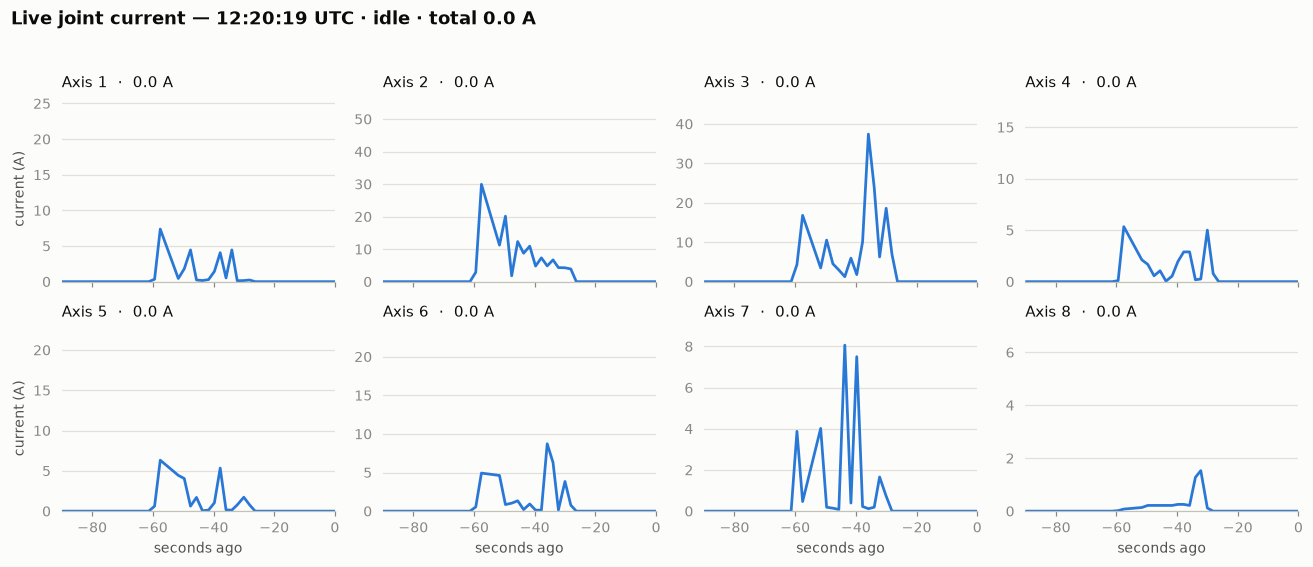

streamed 60 readings; gap between readings 2.01s on average (min 2.00s, max 2.01s)
per reading: 0.40s connecting, inserting, committing and closing; 0.20s redrawing


In [7]:
ss = StreamingSimulator(CSV_PATH, interval=2.0)
board = JointBoard(ceilings)
delivered_at, database_seconds, draw_seconds = [], [], []

for _ in range(STREAM_READINGS):
    record = ss.nextDataPoint()
    delivered_at.append(time.monotonic())
    opened = time.perf_counter()
    with store.connection() as conn:
        store.write(conn, record)
        written = time.perf_counter()
        board.push(record)
        drawn = time.perf_counter()
    closed = time.perf_counter()
    database_seconds.append((written - opened) + (closed - drawn))
    draw_seconds.append(drawn - written)

gaps = np.diff(delivered_at)
print(f"streamed {ss.delivered} readings; gap between readings {gaps.mean():.2f}s on average "
      f"(min {gaps.min():.2f}s, max {gaps.max():.2f}s)")
print(f"per reading: {np.mean(database_seconds):.2f}s connecting, inserting, committing and closing; "
      f"{np.mean(draw_seconds):.2f}s redrawing")

Streamed rows are tagged `origin = 'stream'`, so cleaning up is one `DELETE`, and the foreign key cascades to their joint rows. The history stays untouched, and re-running the notebook never piles up duplicates.

In [8]:
print(f"streamed rows in Neon: {store.count('stream')}")
print(f"deleted {store.purge_stream()} streamed readings; {store.count():,} readings remain, all from the seed")

streamed rows in Neon: 60


deleted 60 streamed readings; 39,672 readings remain, all from the seed


### 🗣 Our talking point — Step 2
**Pace from the clock, not from `sleep(2)`.** Each reading costs a fresh TLS connection to Neon, an insert, a commit and a redraw, about 0.6 s all together (see the output above). Sleeping a flat 2 seconds *after* that work would make every gap about 2.6 s, so the replay would run roughly 30% slower than the controller it imitates, and fall further behind on every reading. The simulator instead waits only for whatever is left of the 2 seconds since the previous reading, and the measured gap stays at about 2.0 s. If the work ever took longer than 2 seconds, the gap would stretch to match rather than readings piling up.

## 🔁 Step 3 — Find patterns in the data stream

### 🗣 Instructor talking point
> Now we document if there are any tendencies or patterns in the data. Do this in the context of the use case and its problem statement.

**Data source.** `dataset/RMBR4-2_export_test.csv`, supplied as CSCN8010 course material (not a public dataset, so no link or licence applies). One Kawasaki material-handling robot, RMBR4-2, recorded from 17 Oct 2022 12:18 to 18 Oct 10:44 UTC. One trait, `current`, in amps, for Axis #1–#8, logged about every 2 seconds.

**Vocabulary.** A reading is *running* if any joint draws current. A **cycle** is an unbroken run of running readings, one pass of the robot's program. An idle stretch of 20 minutes or more counts as a **stoppage**.

In [9]:
running = shift["state"].eq("RUNNING")
cycle_number = (running & ~running.shift(fill_value=False)).cumsum().where(running)
cycles = (
    shift.assign(cycle=cycle_number)
    .dropna(subset=["cycle"])
    .groupby("cycle")
    .agg(start=("sampled_at", "min"), end=("sampled_at", "max"), samples=("state", "size"),
         **{joint: (joint, "max") for joint in JOINTS})
    .reset_index(drop=True)
)
full = cycles["samples"] >= FULL_CYCLE_MIN_SAMPLES
cycle_seconds = (cycles.loc[full, "end"] - cycles.loc[full, "start"]).dt.total_seconds()

idle = ~running
idle_block = idle.ne(idle.shift()).cumsum()
stoppages = (
    shift[idle].groupby(idle_block[idle])
    .agg(start=("sampled_at", "min"), end=("sampled_at", "max"))
    .assign(minutes=lambda frame: (frame["end"] - frame["start"]).dt.total_seconds() / 60)
    .query("minutes >= @STOPPAGE_MINUTES")
    .reset_index(drop=True)
)

gaps = shift["sampled_at"].diff().dt.total_seconds()
j7_peaks = cycles.loc[full, "j7"]
print(f"reading interval: median {gaps.median():.2f}s; {int((gaps > 10).sum())} gaps longer than 10s (longest {gaps.max():.0f}s)")
print(f"running {running.sum():,} readings ({running.mean():.1%}); idle {idle.sum():,} ({idle.mean():.1%})")
print(f"{len(cycles)} bursts of motion: {full.sum()} full cycles (median {cycles.loc[full, 'samples'].median():.0f} readings, "
      f"{cycle_seconds.median():.0f}s) and {(~full).sum()} short moves of 1–4 readings")
print(f"Axis 7 cycle peak: median {j7_peaks.median():.2f} A; "
      f"{(j7_peaks - j7_peaks.median()).abs().lt(0.05).mean():.0%} of full cycles peak within 0.05 A of it")
print(f"peak total current: {shift[JOINTS].sum(axis=1).max():.1f} A")
print(f"\n{len(stoppages)} stoppages of {STOPPAGE_MINUTES}+ minutes:")
for stop in stoppages.itertuples():
    print(f"  {stop.start:%d %b %H:%M} → {stop.end:%H:%M}  {stop.minutes:5.0f} min")

joint_profile = pd.DataFrame({
    "mean while running (A)": shift.loc[running, JOINTS].mean(),
    "highest reading (A)": shift[JOINTS].max(),
    "share of all current": shift[JOINTS].sum() / shift[JOINTS].sum().sum(),
}).rename(index=JOINT_LABELS)
joint_profile.style.format({"mean while running (A)": "{:.2f}", "highest reading (A)": "{:.1f}", "share of all current": "{:.1%}"})

reading interval: median 1.89s; 6 gaps longer than 10s (longest 403s)
running 14,185 readings (35.8%); idle 25,487 (64.2%)
876 bursts of motion: 857 full cycles (median 16 readings, 31s) and 19 short moves of 1–4 readings
Axis 7 cycle peak: median 8.08 A; 99% of full cycles peak within 0.05 A of it
peak total current: 88.1 A

5 stoppages of 20+ minutes:
  17 Oct 15:34 → 16:55     81 min
  17 Oct 17:04 → 17:26     22 min
  17 Oct 21:42 → 22:06     25 min
  18 Oct 03:09 → 05:38    149 min
  18 Oct 05:43 → 06:04     21 min


,mean while running (A),highest reading (A),share of all current
Axis 1,2.03,23.6,7.1%
Axis 2,10.11,51.7,35.4%
Axis 3,7.58,41.9,26.6%
Axis 4,1.73,15.7,6.1%
Axis 5,2.67,20.8,9.4%
Axis 6,1.68,20.9,5.9%
Axis 7,2.43,8.1,8.5%
Axis 8,0.29,5.9,1.0%


**Production rhythm across the shift.** Cycles started per hour show when the robot was producing and when it wasn't. The grey bands are the stoppages.

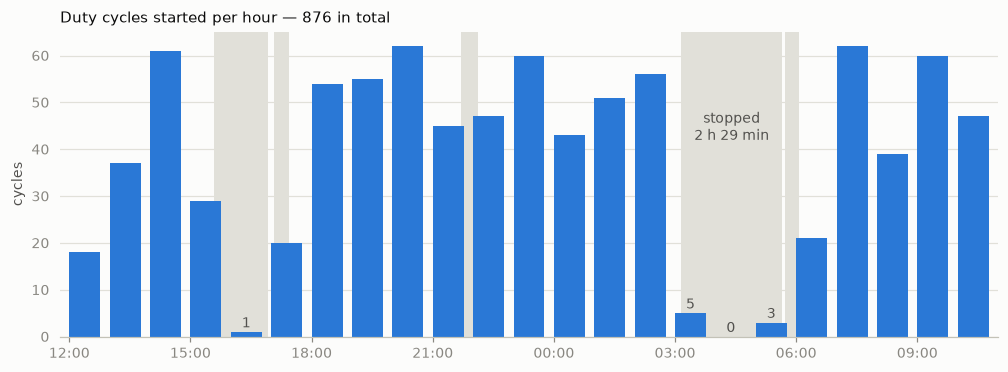

In [10]:
per_hour = cycles.set_index("start").resample("1h").size()

fig, ax = plt.subplots(figsize=(11, 3.6))
for stop in stoppages.itertuples():
    ax.axvspan(stop.start, stop.end, color=GRID, linewidth=0, zorder=0)
ax.bar(per_hour.index, per_hour.values, width=pd.Timedelta(minutes=46), align="edge", color=ACCENT, zorder=2)
for hour, count in per_hour[per_hour <= 5].items():
    ax.annotate(str(count), (hour + pd.Timedelta(minutes=23), count), xytext=(0, 3),
                textcoords="offset points", ha="center", color=INK_2)
longest = stoppages.loc[stoppages["minutes"].idxmax()]
ax.annotate(f"stopped\n{longest.minutes // 60:.0f} h {longest.minutes % 60:.0f} min",
            (longest.start + (longest.end - longest.start) / 2, per_hour.max() * 0.72),
            ha="center", va="center", color=INK_2)
ax.set_title(f"Duty cycles started per hour — {len(cycles)} in total")
ax.set_ylabel("cycles")
ax.xaxis.set_major_formatter(UTC_CLOCK)
ax.margins(x=0.01)
plt.show()

#### Step 3 findings
- **The robot is idle for 64.2% of readings.** Any average that includes idle time describes the production schedule, not the machine, so everything below uses running readings only.
- **It repeats one program.** 857 of 876 bursts of motion are full cycles, almost all 15–18 readings long (about 31 s). In a full working hour it starts 37–62 cycles, a median of 55, close to one a minute.
- **Axes 2 and 3 do the heavy lifting**, averaging 10.1 A and 7.6 A while running and carrying 62% of all current. These are the joints a torque-tube or gearbox problem would load first.
- **Axis 7 hits the same ceiling every cycle.** Its current varies during a move, but 99% of full cycles peak within 0.05 A of 8.08 A, and it never goes above 8.11 A. A hard ceiling like that looks like a current limit on the drive rather than the load changing.
- **Five stoppages of 20+ minutes**, the longest on 18 Oct from 03:09 to 05:38 UTC (about 2 h 29 min). The controller kept logging zeros throughout, so these are production pauses, not data loss.

### 🗣 Our talking point — Step 3
**The regular cycle is what makes comparisons fair.** Comparing raw readings mixes every point of the motion: a joint at rest between moves, accelerating, holding. Because the robot runs the same ~31-second program hundreds of times, **one cycle's peak can be compared with another cycle's peak like for like**. That's why Step 4 scores whole cycles instead of individual samples, and why the 19 short 1–4-reading moves are left out: they aren't the same program.

## 🔍 Step 4 — Anomalies and maintenance notifications

### 🗣 Instructor talking point
> Document the state of the robot(s) after analyzing the data stream.

**Method: calibrate, then compare.** It follows the reference PM dashboard, where each joint's threshold comes from a one-hour calibration cycle.
1. **Calibrate.** A joint's limit is the highest current it drew in any full cycle during the first 60 minutes.
2. **Score every later cycle.** A cycle peak above the limit is a **WARNING**; more than 15% above is **CRITICAL**.
3. **Notify maintenance** when a joint breaks its limit in 4 or more cycles within one clock hour, or has any critical breach. Stoppages are reported too, so someone can confirm they were planned.
4. **Look for drift.** Fit a straight line through each joint's cycle peaks over the whole shift.

In [11]:
full_cycles = cycles[full].reset_index(drop=True)
calibration_end = shift["sampled_at"].min() + pd.Timedelta(minutes=CALIBRATION_MINUTES)
calibration = full_cycles[full_cycles["start"] < calibration_end]
scored = full_cycles[full_cycles["start"] >= calibration_end]
limits = calibration[JOINTS].max()

peaks = scored.melt(id_vars="start", value_vars=JOINTS, var_name="joint", value_name="peak_A")
peaks["limit_A"] = peaks["joint"].map(limits)
peaks["over_pct"] = (peaks["peak_A"] / peaks["limit_A"] - 1) * 100
breaches = peaks[peaks["over_pct"] > 0].copy()
breaches["level"] = np.where(breaches["over_pct"] > CRITICAL_MARGIN * 100, "CRITICAL", "WARNING")

chance = len(scored) / (len(calibration) + 1)
per_joint = pd.DataFrame({
    "limit (A)": limits,
    "breaches": breaches.groupby("joint").size(),
    "critical": breaches.query("level == 'CRITICAL'").groupby("joint").size(),
}).reindex(JOINTS).fillna(0).astype({"breaches": int, "critical": int})
per_joint["breach rate"] = per_joint["breaches"] / len(scored)

print(f"calibration: {len(calibration)} full cycles before {calibration_end:%H:%M} UTC; scored: {len(scored)} cycles after")
print(f"cycles with at least one breach: {breaches['start'].nunique()} of {len(scored)}")
print(f"expected breaches per joint if nothing changed: {len(scored)} / ({len(calibration)} + 1) ≈ {chance:.1f}")
per_joint.rename(index=JOINT_LABELS).style.format({"limit (A)": "{:.2f}", "breach rate": "{:.1%}"})

calibration: 29 full cycles before 13:18 UTC; scored: 828 cycles after
cycles with at least one breach: 129 of 828
expected breaches per joint if nothing changed: 828 / (29 + 1) ≈ 27.6


,limit (A),breaches,critical,breach rate
Axis 1,22.12,17,0,2.1%
Axis 2,47.23,27,0,3.3%
Axis 3,37.43,26,0,3.1%
Axis 4,14.50,22,0,2.7%
Axis 5,19.33,21,0,2.5%
Axis 6,19.07,15,0,1.8%
Axis 7,8.11,0,0,0.0%
Axis 8,4.63,12,1,1.4%


In [12]:
clusters = (
    breaches.assign(hour=breaches["start"].dt.floor("h"))
    .groupby(["hour", "joint"])
    .agg(count=("peak_A", "size"), worst=("over_pct", "max"))
    .query("count >= @NOTIFY_AFTER_BREACHES")
    .reset_index()
)
notices = pd.concat([
    pd.DataFrame({
        "when": clusters["hour"],
        "type": "repeated breaches",
        "joint": clusters["joint"].map(JOINT_LABELS),
        "detail": [f"{row.count} cycles over limit in this hour, worst +{row.worst:.1f}%" for row in clusters.itertuples()],
    }),
    pd.DataFrame({
        "when": breaches.query("level == 'CRITICAL'")["start"],
        "type": "critical breach",
        "joint": breaches.query("level == 'CRITICAL'")["joint"].map(JOINT_LABELS),
        "detail": [f"{row.peak_A:.2f} A against a {row.limit_A:.2f} A limit (+{row.over_pct:.1f}%)"
                   for row in breaches.query("level == 'CRITICAL'").itertuples()],
    }),
    pd.DataFrame({
        "when": stoppages["start"],
        "type": "production stop",
        "joint": "all",
        "detail": [f"no motion for {minutes:.0f} min; confirm it was planned" for minutes in stoppages["minutes"]],
    }),
]).sort_values("when", ignore_index=True)
notices["when"] = notices["when"].dt.strftime("%d %b %H:%M")
print(f"{len(notices)} maintenance notifications")
notices

10 maintenance notifications


,when,type,joint,detail
0,17 Oct 15:34,production stop,all,no motion for 81 min; confirm it was planned
1,17 Oct 17:04,production stop,all,no motion for 22 min; confirm it was planned
2,17 Oct 21:42,production stop,all,no motion for 25 min; confirm it was planned
3,17 Oct 22:00,repeated breaches,Axis 3,"4 cycles over limit in this hour, worst +7.2%"
4,18 Oct 00:00,repeated breaches,Axis 5,"5 cycles over limit in this hour, worst +4.3%"
5,18 Oct 01:53,critical breach,Axis 8,5.91 A against a 4.63 A limit (+27.5%)
6,18 Oct 02:00,repeated breaches,Axis 2,"5 cycles over limit in this hour, worst +6.4%"
7,18 Oct 03:09,production stop,all,no motion for 149 min; confirm it was planned
8,18 Oct 05:43,production stop,all,no motion for 21 min; confirm it was planned
9,18 Oct 09:00,repeated breaches,Axis 3,"4 cycles over limit in this hour, worst +7.2%"


In [13]:
hours_in = (full_cycles["start"] - full_cycles["start"].min()).dt.total_seconds() / 3600
trend_rows = []
for joint in JOINTS:
    slope, intercept = np.polyfit(hours_in, full_cycles[joint], 1)
    r = np.corrcoef(hours_in, full_cycles[joint])[0, 1]
    t = r * np.sqrt((len(hours_in) - 2) / (1 - r**2))
    trend_rows.append({"joint": JOINT_LABELS[joint], "slope (A/h)": slope, "change over shift (A)": slope * hours_in.max(),
                       "r": r, "t": t, "drift?": "yes" if abs(t) > 2 else "no"})
trend = pd.DataFrame(trend_rows).set_index("joint")
print(f"straight-line fit through {len(full_cycles)} cycle peaks per joint, {hours_in.max():.1f} hours")
trend.style.format({"slope (A/h)": "{:+.3f}", "change over shift (A)": "{:+.2f}", "r": "{:+.3f}", "t": "{:+.2f}"})

straight-line fit through 857 cycle peaks per joint, 22.4 hours


,slope (A/h),change over shift (A),r,t,drift?
joint,,,,,
Axis 1,-0.035,-0.79,-0.044,-1.29,no
Axis 2,+0.046,+1.03,+0.032,+0.94,no
Axis 3,-0.028,-0.62,-0.025,-0.74,no
Axis 4,+0.004,+0.09,+0.008,+0.23,no
Axis 5,-0.010,-0.23,-0.018,-0.53,no
Axis 6,+0.020,+0.45,+0.032,+0.92,no
Axis 7,+0.000,+0.01,+0.014,+0.40,no
Axis 8,+0.008,+0.17,+0.040,+1.18,no


**Trend and alert chart.** Grey dots are cycle peaks, the dashed line is each joint's calibration limit, and the blue line is the fitted trend. Breaches are marked in the status colours, and each panel's title gives its count.

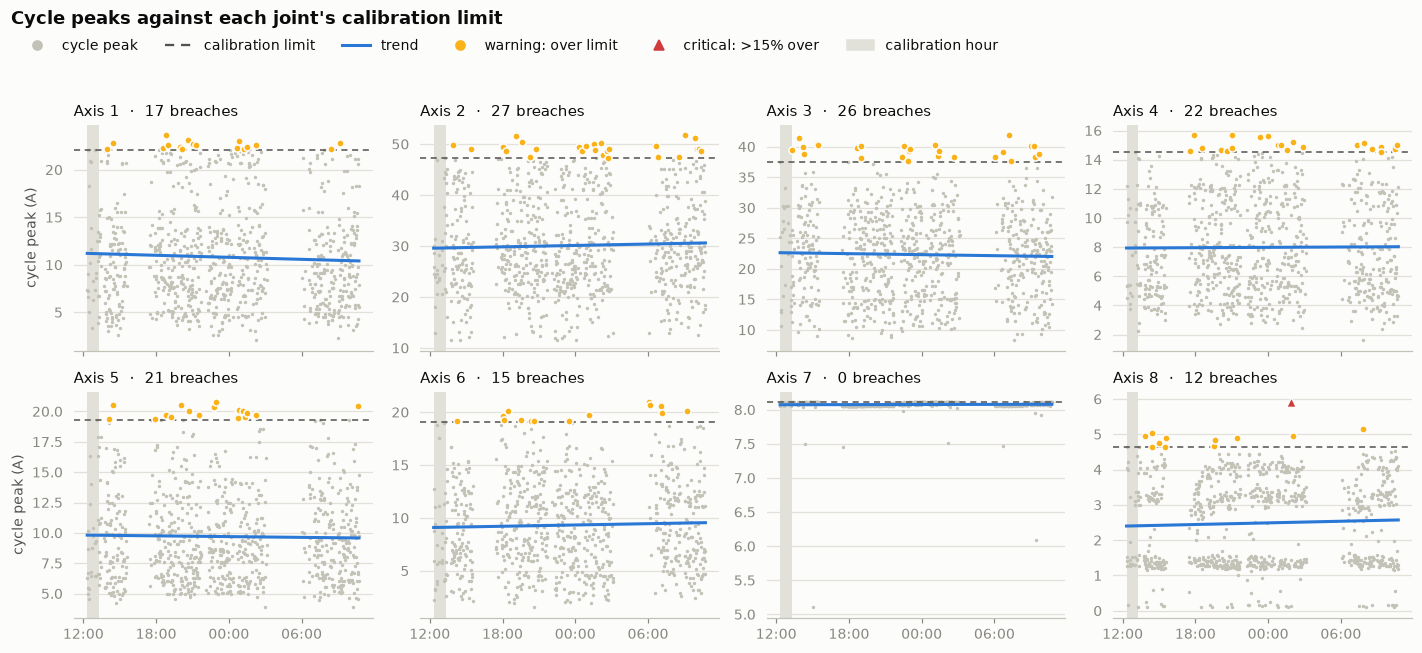

In [14]:
fig, grid = plt.subplots(2, 4, figsize=(13, 6), sharex=True)
for joint, ax in zip(JOINTS, grid.flat):
    hits = breaches[breaches["joint"] == joint]
    warn, crit = hits[hits["level"] == "WARNING"], hits[hits["level"] == "CRITICAL"]
    ax.axvspan(full_cycles["start"].min(), calibration_end, color=GRID, linewidth=0, zorder=0)
    ax.scatter(full_cycles["start"], full_cycles[joint], s=5, color=BASELINE, linewidths=0, zorder=1)
    ax.axhline(limits[joint], color=INK_2, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
    ends = full_cycles["start"].iloc[[0, -1]]
    slope, intercept = np.polyfit(hours_in, full_cycles[joint], 1)
    ax.plot(ends, intercept + slope * hours_in.iloc[[0, -1]].to_numpy(), color=ACCENT, linewidth=2, zorder=3)
    ax.scatter(warn["start"], warn["peak_A"], s=22, color=WARNING, edgecolors=SURFACE, linewidths=1, zorder=4)
    ax.scatter(crit["start"], crit["peak_A"], s=42, marker="^", color=CRITICAL, edgecolors=SURFACE, linewidths=1, zorder=5)
    ax.set_title(f"{JOINT_LABELS[joint]}  ·  {len(hits)} breaches")
    ax.xaxis.set_major_formatter(UTC_CLOCK)
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 6), tz="UTC"))
for ax in grid[:, 0]:
    ax.set_ylabel("cycle peak (A)")

key = [
    Line2D([], [], marker="o", linestyle="", color=BASELINE, label="cycle peak"),
    Line2D([], [], color=INK_2, linestyle=(0, (4, 3)), label="calibration limit"),
    Line2D([], [], color=ACCENT, linewidth=2, label="trend"),
    Line2D([], [], marker="o", linestyle="", color=WARNING, label="warning: over limit"),
    Line2D([], [], marker="^", linestyle="", color=CRITICAL, label="critical: >15% over"),
    Patch(color=GRID, label="calibration hour"),
]
fig.suptitle("Cycle peaks against each joint's calibration limit", x=0.01, ha="left")
fig.legend(handles=key, loc="upper left", bbox_to_anchor=(0.01, 0.955), ncol=6, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

#### Step 4 findings: the state of the robot
- **Breaches happen, but no more often than chance.** A limit taken from 29 calibration cycles will be beaten by about 1 cycle in 30 even if nothing changes, which works out to ≈27.6 of the 828 scored cycles. Every joint lands at or below that: 0 to 27 breaches each.
- **One critical breach, on Axis 8**, the lightest joint, where a small absolute step is a large percentage.
- **Axis 7 never breaches.** Its peak is the same ~8.1 A ceiling every cycle (Step 3), so the calibration limit already sits at that ceiling. A limit taken from a clipped signal can't detect anything, which is worth knowing before trusting it.
- **No drift.** Every joint's trend has |t| below 1.3, well short of 2. The largest change over the 22 hours is Axis 2's cycle peak rising about 1 A, roughly 3% of its typical 30 A peak, which is inside the noise.
- **The anomalies don't change the robot's state:** it keeps completing cycles after every breach. Its **condition is healthy**, and the notifications are prompts for a person to look, not evidence of a fault. The one cluster worth a note is Axis 2 in the 02:00 hour, just before the 2½-hour stop at 03:09. The data can't say whether that stop was planned. Routing that question to maintenance is exactly what the notification is for.

### 🗣 Our talking point — Step 4
**A breach count means nothing until it's compared with chance.** Our first reading of the table was "129 cycles broke a limit, so something is wrong." But a limit set from the maximum of $n$ cycles will be beaten by a later healthy cycle with probability $1/(n+1)$. With $n = 29$, that's one cycle in 30. The honest test isn't *did it breach* but *does it breach more often than 1 in 30*. On this shift no joint does. A wearing torque tube would show up as a joint whose breach rate climbs well above the chance line and whose trend has $|t| > 2$. That combination is the alarm to build towards once weeks of data exist, not 22 hours.

## 🔎 Phrase query tests
Two plain-English questions, each answered by SQL against Neon and checked against the in-memory DataFrame from Step 1. A test passes only if the database and pandas agree.

**Phrase query 1: "Which joint draws the most current while the robot is running?"**

In [15]:
answer = store.ask(f'''
    SELECT j.label, round(avg(c.amps)::numeric, 2) AS mean_running_amps
    FROM {SCHEMA}.joint_current c
    JOIN {SCHEMA}.sample s USING (sample_id)
    JOIN {SCHEMA}.joint j USING (joint_id)
    WHERE s.origin = 'seed' AND s.state = 'RUNNING'
    GROUP BY j.label
    ORDER BY mean_running_amps DESC
    LIMIT 3
''')
display(answer)

in_memory = shift.loc[running, JOINTS].mean()
assert answer.loc[0, "label"] == f"Axis #{in_memory.idxmax().removeprefix('j')}"
assert abs(float(answer.loc[0, "mean_running_amps"]) - in_memory.max()) < 0.01
print(f"PASS: {answer.loc[0, 'label']} averages {float(answer.loc[0, 'mean_running_amps']):.2f} A in both Neon and pandas")

,label,mean_running_amps
0,Axis #2,10.11
1,Axis #3,7.58
2,Axis #5,2.67


PASS: Axis #2 averages 10.11 A in both Neon and pandas


**Phrase query 2: "How many duty cycles did the robot start during the shift?"** A cycle starts wherever a running reading follows an idle one. SQL finds those with the `lag()` window function.

In [16]:
answer = store.ask(f'''
    SELECT count(*) AS cycles_started
    FROM (
        SELECT state, lag(state) OVER (ORDER BY sampled_at) AS previous_state
        FROM {SCHEMA}.sample
        WHERE origin = 'seed'
    ) readings
    WHERE state = 'RUNNING' AND previous_state IS DISTINCT FROM 'RUNNING'
''')
display(answer)

assert int(answer.loc[0, "cycles_started"]) == len(cycles)
print(f"PASS: Neon counts {int(answer.loc[0, 'cycles_started'])} cycle starts; pandas found {len(cycles)}")

,cycles_started
0,876


PASS: Neon counts 876 cycle starts; pandas found 876


## 🧠 Additional challenge — the whole data set on one chart
The whole shift, read back from the database, as the **charge each joint drew in each hour** (amp-hours: current × time between readings). The controller reports no voltage, so this compares the joints' consumption rather than giving true energy. PostgreSQL does the aggregation: `lead()` finds the time to the next reading, capped at 4 s so the six recording gaps don't count as minutes of current nobody measured.

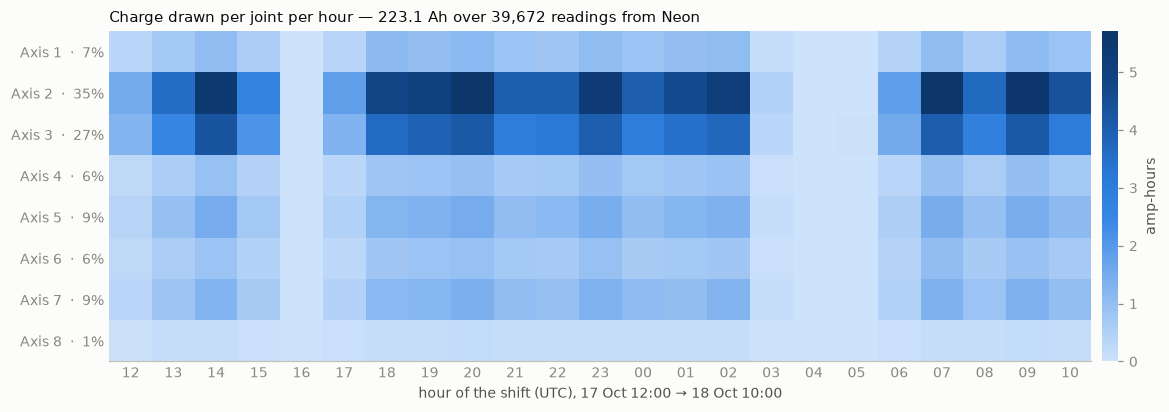

,amp-hours,share,busiest hour (UTC)
Axis 1,15.94,7.1%,17 Oct 20:00
Axis 2,79.04,35.4%,17 Oct 20:00
Axis 3,59.25,26.6%,17 Oct 14:00
Axis 4,13.57,6.1%,18 Oct 09:00
Axis 5,20.89,9.4%,17 Oct 14:00
Axis 6,13.16,5.9%,18 Oct 07:00
Axis 7,19.01,8.5%,17 Oct 20:00
Axis 8,2.23,1.0%,18 Oct 09:00


In [17]:
charge = store.ask(f'''
    WITH timed AS (
        SELECT sample_id, sampled_at,
               LEAST(EXTRACT(EPOCH FROM lead(sampled_at) OVER (ORDER BY sampled_at) - sampled_at), 4) AS seconds
        FROM {SCHEMA}.sample
        WHERE origin = 'seed'
    )
    SELECT date_trunc('hour', t.sampled_at AT TIME ZONE 'UTC') AS hour,
           c.joint_id,
           sum(c.amps * coalesce(t.seconds, 0)) / 3600 AS amp_hours
    FROM timed t
    JOIN {SCHEMA}.joint_current c USING (sample_id)
    GROUP BY 1, 2
    ORDER BY 1, 2
''')
heat = charge.pivot(index="joint_id", columns="hour", values="amp_hours")
totals = heat.sum(axis=1)
share = totals / totals.sum()

fig, ax = plt.subplots(figsize=(12, 3.9))
image = ax.imshow(heat.to_numpy(), aspect="auto", cmap=BLUE_RAMP, vmin=0, interpolation="nearest")
ax.grid(False)
ax.set_yticks(range(len(heat)), [f"Axis {n}  ·  {share[n]:.0%}" for n in heat.index])
ax.set_xticks(range(len(heat.columns)), [f"{hour:%H}" for hour in heat.columns])
ax.set_xlabel("hour of the shift (UTC), 17 Oct 12:00 → 18 Oct 10:00")
ax.set_title(f"Charge drawn per joint per hour — {totals.sum():.1f} Ah over {store.count('seed'):,} readings from Neon")
ax.tick_params(length=0)
bar = fig.colorbar(image, ax=ax, pad=0.01, fraction=0.03)
bar.set_label("amp-hours", color=INK_2)
bar.outline.set_visible(False)
plt.show()

summary = pd.DataFrame({"amp-hours": totals, "share": share, "busiest hour (UTC)": heat.idxmax(axis=1).dt.strftime("%d %b %H:00")})
summary.index = [f"Axis {n}" for n in summary.index]
summary.style.format({"amp-hours": "{:.2f}", "share": "{:.1%}"})

**Reading it.** Two horizontal bands dominate: Axis 2 and Axis 3 draw most of the robot's charge in every working hour. The pale columns are the stoppages, including the empty 04:00 hour. The pattern is the same from start to finish. Nothing in the consumption points to a joint getting worse over the shift, which agrees with the flat trends in Step 4.

A standalone web version of the live board, with calibration meters and an anomaly log, is in `monitor_web/`. See the README to run it.